# Sensitivity analysis of intermediate variables uncertainty to input errors : contribution of pedoclimatic response functions to uncertainty of mineralisation rate


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Math


## AMGv2 parameters

From Clivot et al. (2019) : https://doi.org/10.1016/j.envsoft.2019.04.004

In [23]:
# AMGv2 params in a dictionnary

param={}
param['a_calcium'] = 0.0015
param['a_pH']      = 0.112
param['b_pH']      = 8.5
param['a_clay']    = 2.519*1e-3
param['a_CN']      = 0.06
param['b_CN']      = 11
param['c_CN']      = 0.8
param['d_CN']      = 0.2
param['a_H']       = 0.03
param['b_H']       = 5.247
param['a_T']       = 25
param['T_ref']     = 15
param['c_T']       = 0.12
param['b_T']       = (param['a_T']-1)*np.exp(param['c_T'] *param['T_ref'] )
param['k0']        = 0.290

Load data from experimental sites studied in Clivot et al. (2019) :

In [25]:
data_clivot = pd.read_csv('../data/work_scenario_Clivot_et_al_2019_suplemental.csv')


## Contribution of soil-climate function response to uncertainty of mineralisation rate

In the paper, we show in equation 2.12 that the expression of the uncertainty of the mineralisation rate k is a sum of each pedoclimatic function uncertainty contribution.

$
\sigma_{k}^2 = k^2 \sum_{i=1}^{N} \left (\frac{ f_{i}'(x_i)}{f_{i}(x_i)} \right)^2\sigma_{x_i}^2    
$


 Here we compute each function contribution to the uncertainty. First, we compute each $\left (\frac{ f_{i}'(x_i)}{f_{i}(x_i)} \right)$, via the different eps_f() functions.

In [34]:
def eps_fT(param, T):
    b_T = param['b_T']
    c_T = param['c_T']
    eps = b_T * c_T * np.exp(-c_T*T) / (1 + b_T*np.exp(-c_T*T))
    return eps


def eps_CaCO3(param,CACO3):
    c_m = param['a_calcium']
    return - c_m/(1+c_m*CACO3)

def eps_pH(param, pH):
    a_pH = param['a_pH']
    b_pH = param['b_pH']
    return -2*a_pH*(pH-b_pH)

def eps_CN(param,CN_ratio):
    a_CN = param['a_CN']
    b_CN = param['b_CN']    
    fp_CN = -1.6 * a_CN *(CN_ratio- b_CN)*np.exp(-a_CN *(CN_ratio-b_CN)**2)
    f = 0.8 * np.exp(-a_CN*(CN_ratio-b_CN)**2) + 0.2
    return fp_CN/f

def eps_Hm(param, Hm):
    a_H = param['a_H']
    b_H = param['b_H']
    eps = (a_H*b_H*np.exp(-b_H*Hm/1000))/(1000*(1+ a_H*np.exp(-b_H*Hm/1000)))
    return eps



# DATA

### Creation of pedoclimatic variables ranges


In [5]:
n=500

# soil variables dictionnary
soil={}
soil['Clay']    = np.linspace(1e-10,600,n)
soil['CACO3']   = np.linspace(1e-10,900,n)
soil['pH']      = np.linspace(4,9,n)
soil['CN_ratio']= np.linspace(5,15,n)

# climatic variables dictionnary
forc ={}
forc['Temperature']= np.linspace(5,20,n)
forc['Rain']       = np.linspace(200,2000,n)
forc['PET']        = np.linspace(200,1200,n)
forc['Hm']         = np.linspace(-500,1000,n) # Hm = Rain - PET (+ irrigation)
Hm                 = np.linspace(-500,1000,n)


### Ranges of pedoclimatic variables in which the model AMGv2 has been validated in Clivot et al. (2019)

In [6]:
# ranges values where AMGv2 was validated in Clivot et al. 2019
val={}
val['Clay']       = soil['Clay'][np.where((soil['Clay']>=43) & (soil['Clay']<=308))]
val['CACO3']      = soil['CACO3'][np.where((soil['CACO3']<=781))]
val['pH']         = soil['pH'][np.where((soil['pH']>=5.6) & (soil['pH']<=8.3))]
val['CN_ratio']   = soil['CN_ratio'][np.where((soil['CN_ratio']>=7.8)&(soil['CN_ratio']<=13))]
val['Temperature']= forc['Temperature'][np.where((forc['Temperature']>=9.9) & (forc['Temperature']<=13.5))]
val['Rain']       = forc['Rain'][np.where((forc['Rain']>=0.637) & (forc['Rain']<=1.285))]
val['PET']        = forc['PET'][np.where((forc['PET']>=0.637) & (forc['PET']<=0.947))]
val['Hm']         = Hm[np.where((Hm>=-290) & (Hm<=595))]


# indexes of the points of soil and forc data included in the validation ranges
val_index={}
val_index['Clay']        = np.where((soil['Clay']>=43) & (soil['Clay']<=308))
val_index['CACO3']       = np.where((soil['CACO3']<=781))
val_index['pH']          = np.where((soil['pH']>=5.6) & (soil['pH']<=8.3))
val_index['CN_ratio']    = np.where((soil['CN_ratio']>=7.8)&(soil['CN_ratio']<=13))
val_index['Temperature'] = np.where((forc['Temperature']>=9.9) & (forc['Temperature']<=13.5))
val_index['Rain']        = np.where((forc['Rain']>=0.637) & (forc['Rain']<=1.285))
val_index['PET']         = np.where((forc['PET']>=0.637) & (forc['PET']<=0.947))
val_index['Hm']          = np.where((Hm>=-290) & (Hm<=595))





def normalize(a):
    a_norm = (a - a.min(axis=0)) / (a.max(axis=0) - a.min(axis=0))
    return a_norm

T_norm = normalize(forc['Temperature'])


## Error values in Large-scale error scenario

In [14]:
# sigma values for soil from Ballabio et al. (2016) and (2019) (LUCAS mapping)
sigma_LS={}

sigma_LS['Clay']    = 77
sigma_LS['CACO3']   = 78.29
sigma_LS['pH']      = 0.78 # I took the max sigma which correspond to pH in H20 (otherwise sigma = 0.68 for pH in CaCl2)
sigma_LS['CN_ratio']= 1.97


# sigma values for temperature, rain and ETO from comparasion studies between ERA5 reanalyses and local data

sigma_LS['Temperature']= 1.97/np.sqrt(365) # worst case in Vanella et al. (2022) : error of Tair daily from ERA5 compared with measure=> we divise by sqrt(N days) to have mean annual, otherwise 1 in Liu et al 2024 but not really comparison with local data
sigma_LS['Rain']       = 95.5 #worst case in Lavers et al. (2022)
sigma_LS['PET']        = 16.81 #worst case in Vanella et al. (2022)
sigma_LS['Hm2']        = sigma_LS['Rain']**2 + sigma_LS['PET']**2
sigma_LS['Hm']         = np.sqrt(sigma_LS['Rain']**2 + sigma_LS['PET']**2)



## Error values in Field-scale error scenario, assuming 10% of relative error (except temperature at 1% of relative error)

In [15]:
err_rel_10  = 0.1  # 10% of relative error
err_rel_T_1 = 0.01 # 1% of relative error for the temperature


sigma_FS={}
sigma_FS['Clay']    = soil['Clay']*err_rel_10
sigma_FS['CACO3']   = soil['CACO3']*err_rel_10
sigma_FS['pH']      = soil['pH']*err_rel_10
sigma_FS['CN_ratio']= soil['CN_ratio']*err_rel_10


sigma_FS['Temperature']= forc['Temperature'] *err_rel_T_1
sigma_FS['Rain']       = forc['Rain']*err_rel_10
sigma_FS['PET']        = forc['PET']*err_rel_10
sigma_FS['Hm2']        = sigma_FS['Rain']**2 + sigma_FS['PET']**2
sigma_FS['Hm']         = np.sqrt(sigma_FS['Rain']**2 + sigma_FS['PET']**2)

### Extra worst case scenario, 100% of relative error 

err_rel_100 = 1 # 100% of relative error

sigma_rel_100={}
sigma_rel_100['Clay']    = soil['Clay']*err_rel_100
sigma_rel_100['CACO3']   = soil['CACO3']*err_rel_100
sigma_rel_100['pH']      = soil['pH']*err_rel_100
sigma_rel_100['CN_ratio']= soil['CN_ratio']*err_rel_100


sigma_rel_100['Temperature']= forc['Temperature'] *err_rel_100
sigma_rel_100['Rain']       = forc['Rain']*err_rel_100
sigma_rel_100['PET']        = forc['PET']*err_rel_100
sigma_rel_100['Hm2']        = sigma_rel_100['Rain']**2 + sigma_rel_100['PET']**2
sigma_rel_100['Hm']         = np.sqrt(sigma_rel_100['Rain']**2 + sigma_rel_100['PET']**2)

# RESULTS

# Graphic for Field-scale error scenario, with 10% relative error (except for temperature with 1% of relative error) Fig. 7a

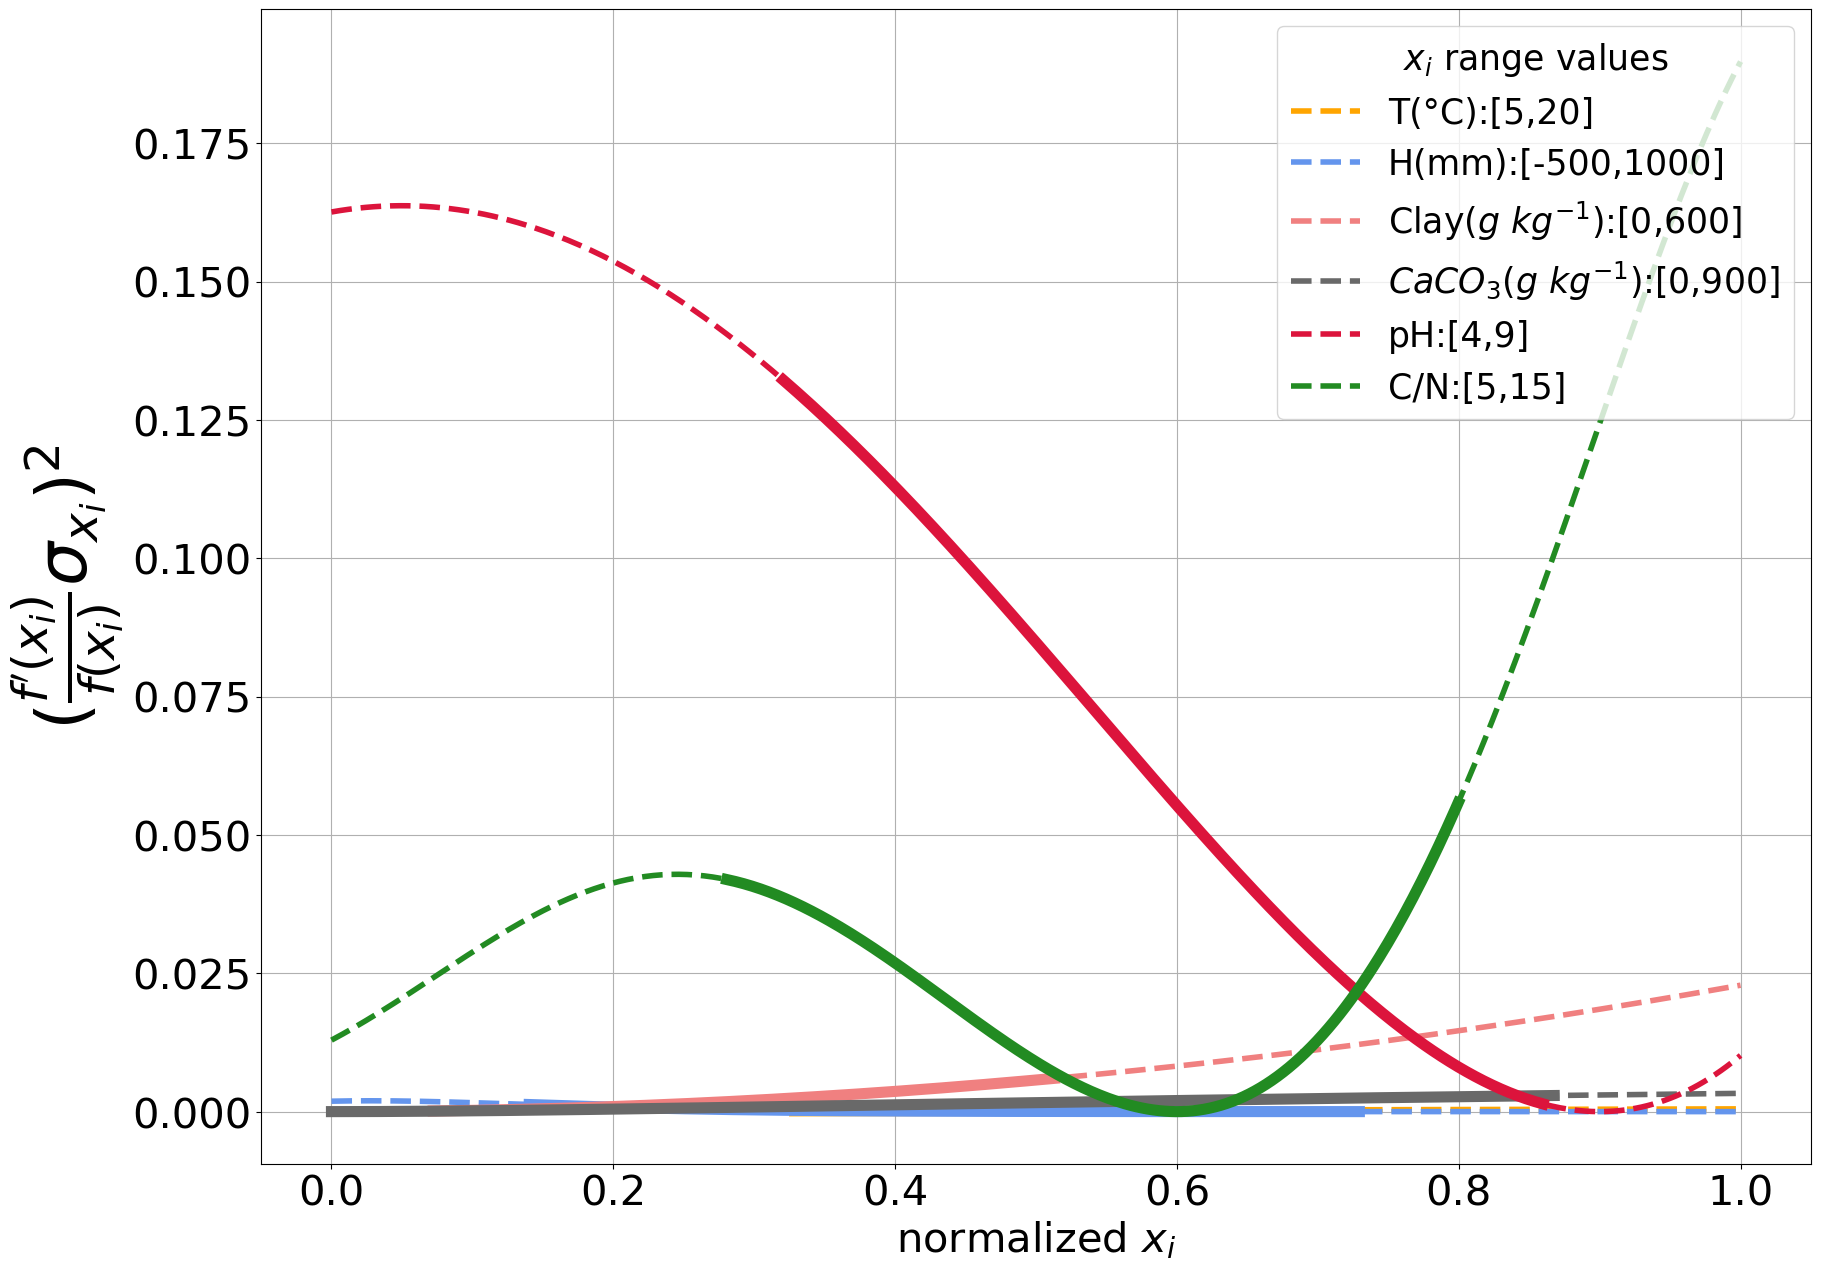

In [41]:
#%% normalize variable to plot everything on one graph

plt.figure(figsize=[20,15]) 

plt.plot(normalize(forc['Temperature']), (sigma_FS['Temperature']*eps_fT(param, forc['Temperature']))**2,
         label='T(°C):[5,20]',linestyle='dashed', linewidth=4, color='orange')
plt.plot(normalize(forc['Temperature'])[val_index['Temperature']], 
         (sigma_FS['Temperature'][val_index['Temperature']]*eps_fT(param, val['Temperature']))**2,
         linewidth=8,color='orange')

plt.plot(normalize(Hm), (sigma_FS['Hm']*eps_Hm(param, Hm))**2,
         label='H(mm):[-500,1000]',linestyle='dashed', linewidth=4, color='cornflowerblue')
plt.plot(normalize(Hm)[val_index['Hm']], (sigma_FS['Hm'][val_index['Hm']]*eps_Hm(param, val['Hm']))**2,  
         linewidth=8, color='cornflowerblue')

plt.plot(normalize(soil['Clay']), (sigma_FS['Clay']*param['a_clay'] )**2, 
         label='Clay($g~kg^{-1}$):[0,600]',linestyle='dashed', linewidth=4, color='lightcoral')
plt.plot(normalize(soil['Clay'])[val_index['Clay']], (sigma_FS['Clay'][val_index['Clay']]*param['a_clay'] )**2, 
         linewidth=8, color='lightcoral')

plt.plot(normalize(soil['CACO3']), (sigma_FS['CACO3']*eps_CaCO3(param,soil['CACO3']))**2,
         label='$CaCO_3$($g~kg^{-1}$):[0,900]',linestyle='dashed', linewidth=4, color='dimgray')
plt.plot(normalize(soil['CACO3'])[val_index['CACO3']], 
         (sigma_FS['CACO3'][val_index['CACO3']]*eps_CaCO3(param,val['CACO3']))**2, linewidth=8, color='dimgray')

plt.plot(normalize(soil['pH']), (sigma_FS['pH']*eps_pH(param,soil['pH']))**2, 
         label='pH:[4,9]',linestyle='dashed', linewidth=4, color='crimson')
plt.plot(normalize(soil['pH'])[val_index['pH']], (sigma_FS['pH'][val_index['pH']]*eps_pH(param,val['pH']))**2,
         linewidth=8, color='crimson')

plt.plot(normalize(soil['CN_ratio']), (sigma_FS['CN_ratio']*eps_CN(param,soil['CN_ratio']))**2, 
         label='C/N:[5,15]',linestyle='dashed', linewidth=4, color='forestgreen')
plt.plot(normalize(soil['CN_ratio'])[val_index['CN_ratio']], 
         (sigma_FS['CN_ratio'][val_index['CN_ratio']]*eps_CN(param,val['CN_ratio']))**2,
         linewidth=8, color='forestgreen')

plt.grid()
plt.rcParams['text.usetex'] = False
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('normalized $x_i$', fontsize=30)
plt.ylabel(r"$(\frac{f'(x_i)}{f(x_i)} \sigma_{x_i})^2$", fontsize=50)
plt.legend(
    loc='upper right',
    fontsize=25,
    title=r"$x_i$ range values",
    title_fontsize=25
)



# Graphic for Large-scale error scenario, with fixed errors (Fig. 7.b)

(-0.05, 0.9)

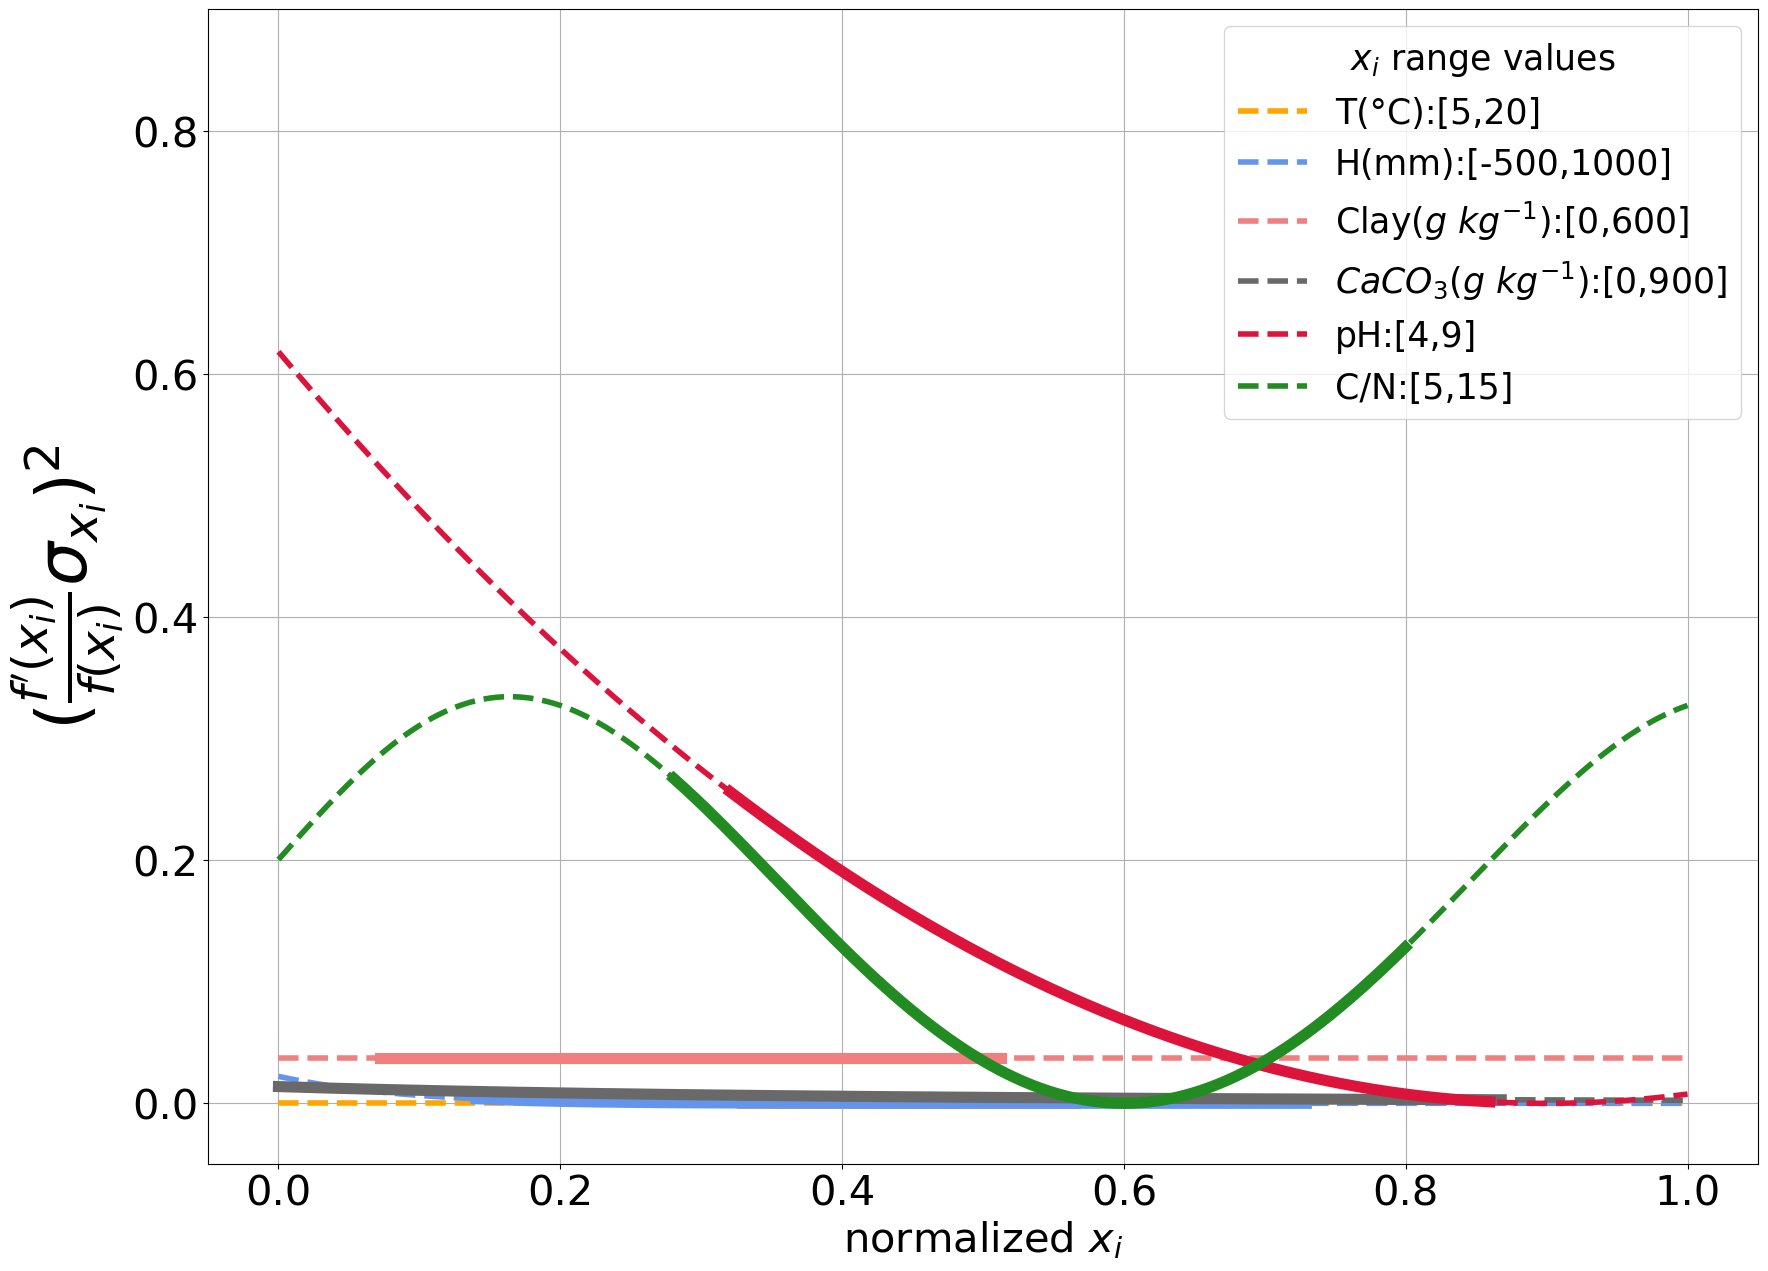

In [42]:
#%% normalise variable to plot everything on one graph, with sigma_xi constant

plt.figure(figsize=[20,15]) 

plt.plot(normalize(forc['Temperature']), (sigma_LS['Temperature']*eps_fT(param, forc['Temperature']))**2,
         label='T(°C):[5,20]',linestyle='dashed', linewidth=4, color='orange')
plt.plot(normalize(forc['Temperature'])[val_index['Temperature']], 
         (sigma_LS['Temperature']*eps_fT(param, val['Temperature']))**2, linewidth=8,color='orange')

plt.plot(normalize(Hm), (sigma_LS['Hm']*eps_Hm(param, Hm))**2, 
         label='H(mm):[-500,1000]',linestyle='dashed', linewidth=4, color='cornflowerblue')
plt.plot(normalize(Hm)[val_index['Hm']], (sigma_LS['Hm']*eps_Hm(param, val['Hm']))**2, 
         linewidth=8, color='cornflowerblue')

ligne_clay = np.zeros(normalize(soil['Clay']).size) + (sigma_LS['Clay']*param['a_clay'] )**2
ligne_clay_val = np.zeros(normalize(soil['Clay'])[val_index['Clay']].size) + (sigma_LS['Clay']*param['a_clay'] )**2

plt.plot(normalize(soil['Clay']), ligne_clay, label='Clay($g~kg^{-1}$):[0,600]',
         linestyle='dashed', linewidth=4, color='lightcoral')
plt.plot(normalize(soil['Clay'])[val_index['Clay']], ligne_clay_val, linewidth=8, color='lightcoral')

plt.plot(normalize(soil['CACO3']), (sigma_LS['CACO3']*eps_CaCO3(param,soil['CACO3']))**2,
         label='$CaCO_3$($g~kg^{-1}$):[0,900]',linestyle='dashed', linewidth=4, color='dimgray')
plt.plot(normalize(soil['CACO3'])[val_index['CACO3']], (sigma_LS['CACO3']*eps_CaCO3(param,val['CACO3']))**2,
         linewidth=8, color='dimgray')

plt.plot(normalize(soil['pH']), (sigma_LS['pH']*eps_pH(param,soil['pH']))**2, 
         label='pH:[4,9]',linestyle='dashed', linewidth=4, color='crimson')
plt.plot(normalize(soil['pH'])[val_index['pH']], (sigma_LS['pH']*eps_pH(param,val['pH']))**2,
         linewidth=8, color='crimson')

plt.plot(normalize(soil['CN_ratio']), (sigma_LS['CN_ratio']*eps_CN(param,soil['CN_ratio']))**2,
         label="C/N:[5,15]",linestyle='dashed', linewidth=4, color='forestgreen')
plt.plot(normalize(soil['CN_ratio'])[val_index['CN_ratio']], (sigma_LS['CN_ratio']*eps_CN(param,val['CN_ratio']))**2,
         linewidth=8, color='forestgreen')


x = np.linspace(0,1,n)
plt.grid()

plt.rcParams['text.usetex'] = False
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('normalized $x_i$', fontsize=30)
plt.ylabel(r"$(\frac{f'(x_i)}{f(x_i)} \sigma_{x_i})^2$", fontsize=50)

plt.legend(
    loc='upper right',
    fontsize=25,
    title=r"$x_i$ range values",
    title_fontsize=25
)
plt.ylim([-0.05, 0.9])

# Graphic worst case scenario with a 100% relative error (Fig. 7.c)

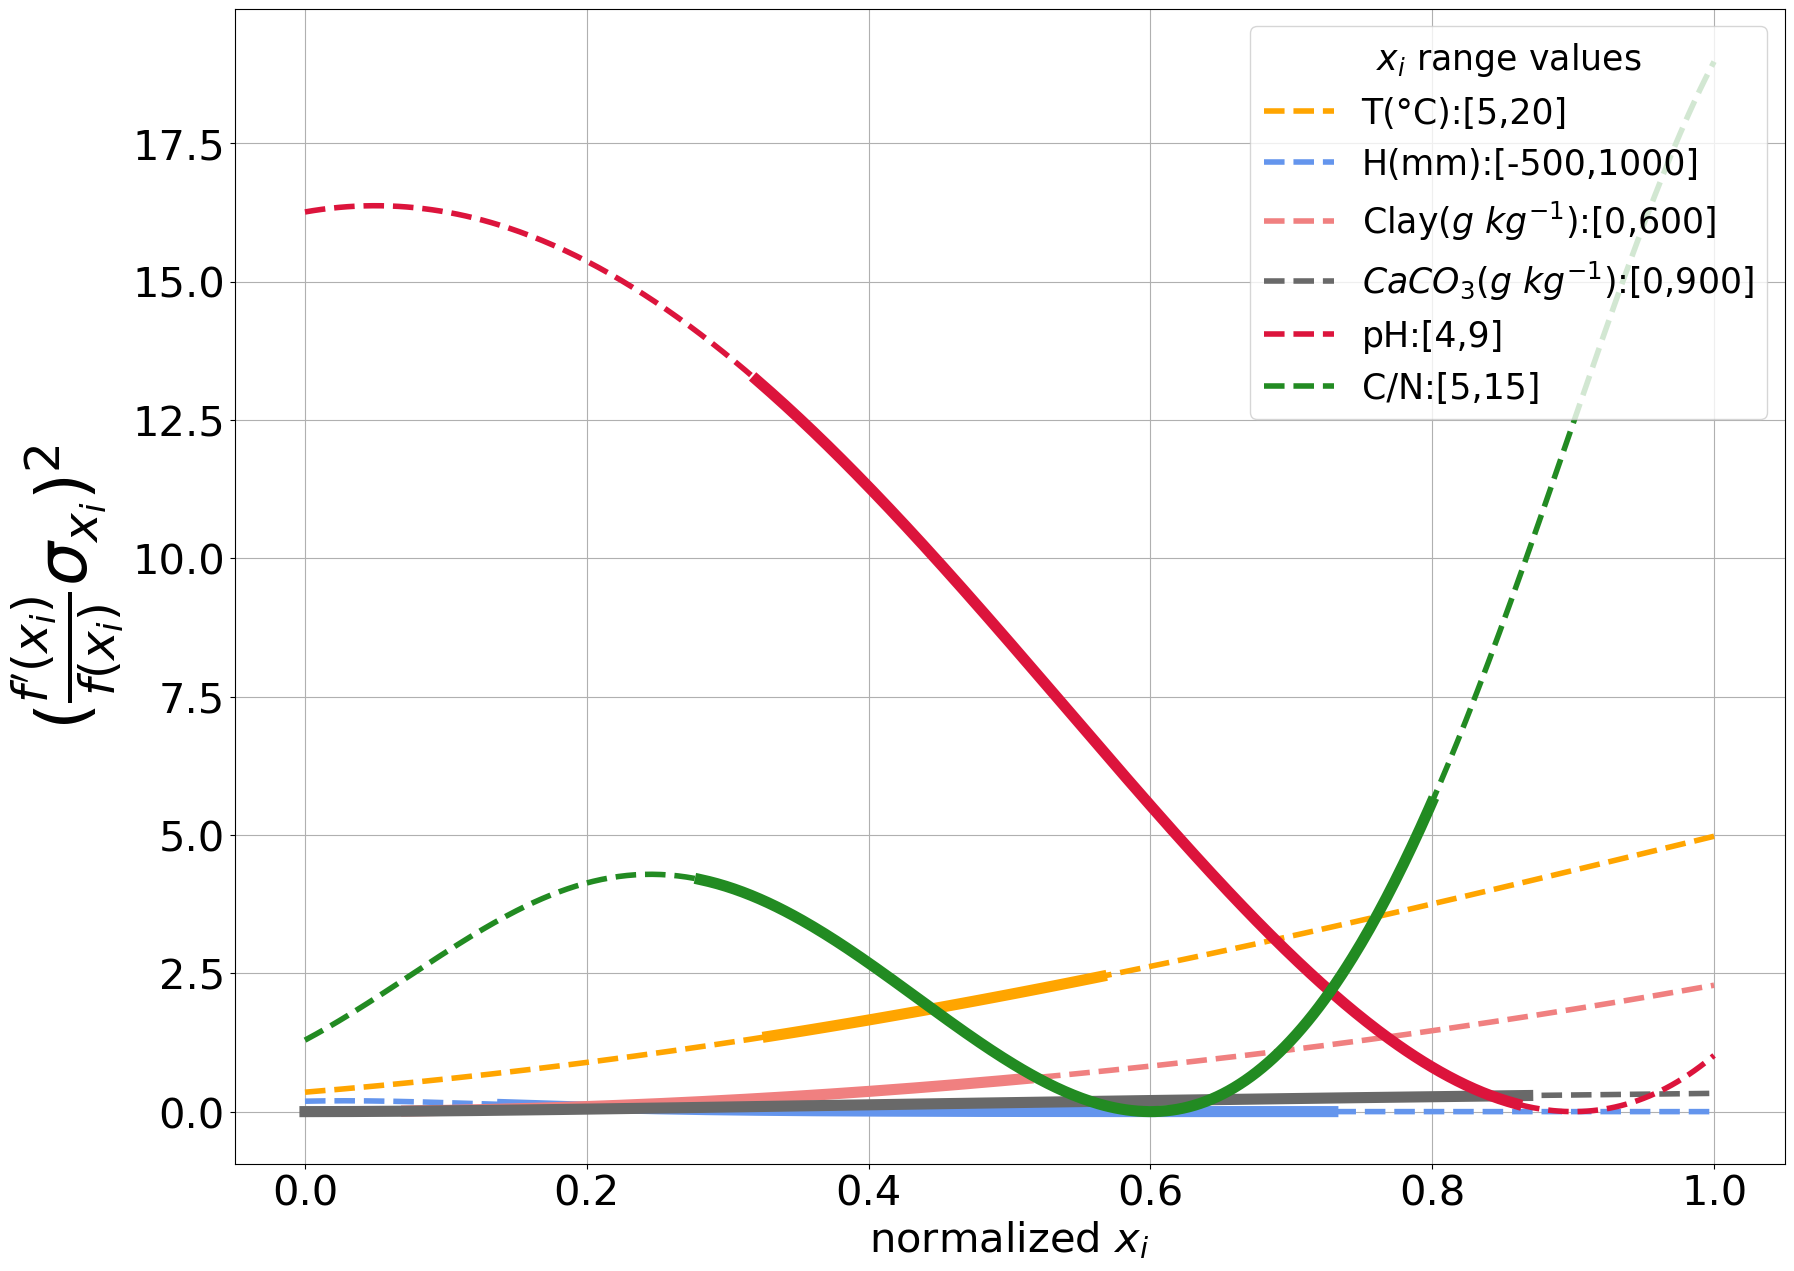

In [45]:
#%% normalize variable to plot everything on one graph, with sigma_xi variable = 10% xi


plt.figure(figsize=[20,15])  

plt.plot(normalize(forc['Temperature']), (sigma_rel_100['Temperature']*eps_fT(param, forc['Temperature']))**2,
         label='T(°C):[5,20]',linestyle='dashed', linewidth=4, color='orange')
plt.plot(normalize(forc['Temperature'])[val_index['Temperature']], 
         (sigma_rel_100['Temperature'][val_index['Temperature']]*eps_fT(param, val['Temperature']))**2,
         linewidth=8,color='orange')

plt.plot(normalize(Hm), (sigma_rel_100['Hm']*eps_Hm(param, Hm))**2, 
         label='H(mm):[-500,1000]',linestyle='dashed', linewidth=4, color='cornflowerblue')
plt.plot(normalize(Hm)[val_index['Hm']], (sigma_rel_100['Hm'][val_index['Hm']]*eps_Hm(param, val['Hm']))**2, 
         linewidth=8, color='cornflowerblue')

plt.plot(normalize(soil['Clay']), (sigma_rel_100['Clay']*param['a_clay'] )**2, 
         label='Clay($g~kg^{-1}$):[0,600]',linestyle='dashed', linewidth=4, color='lightcoral')
plt.plot(normalize(soil['Clay'])[val_index['Clay']], 
         (sigma_rel_100['Clay'][val_index['Clay']]*param['a_clay'] )**2, linewidth=8, color='lightcoral')

plt.plot(normalize(soil['CACO3']), (sigma_rel_100['CACO3']*eps_CaCO3(param,soil['CACO3']))**2,
         label='$CaCO_3$($g~kg^{-1}$):[0,900]',linestyle='dashed', linewidth=4, color='dimgray')
plt.plot(normalize(soil['CACO3'])[val_index['CACO3']], 
         (sigma_rel_100['CACO3'][val_index['CACO3']]*eps_CaCO3(param,val['CACO3']))**2, linewidth=8, color='dimgray')

plt.plot(normalize(soil['pH']), (sigma_rel_100['pH']*eps_pH(param,soil['pH']))**2, 
         label='pH:[4,9]',linestyle='dashed', linewidth=4, color='crimson')
plt.plot(normalize(soil['pH'])[val_index['pH']], 
         (sigma_rel_100['pH'][val_index['pH']]*eps_pH(param,val['pH']))**2,  linewidth=8, color='crimson')


plt.plot(normalize(soil['CN_ratio']), (sigma_rel_100['CN_ratio']*eps_CN(param,soil['CN_ratio']))**2,
         label='C/N:[5,15]',linestyle='dashed', linewidth=4, color='forestgreen')
plt.plot(normalize(soil['CN_ratio'])[val_index['CN_ratio']], 
         (sigma_rel_100['CN_ratio'][val_index['CN_ratio']]*eps_CN(param,val['CN_ratio']))**2,
         linewidth=8, color='forestgreen')

plt.grid()
plt.rcParams['text.usetex'] = False
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel('normalized $x_i$', fontsize=30)
plt.ylabel(r"$(\frac{f'(x_i)}{f(x_i)} \sigma_{x_i})^2$", fontsize=50)
plt.legend(
    loc='upper right',
    fontsize=25,
    title=r"$x_i$ range values",
    title_fontsize=25
)




# SUPPLEMENTAL MATERIAL, Fig. S2

We plot the contribution of each pedoclimatic response function modulating mineralisation rate in an individual graph, for both input error scenarios. Markers represent sites from Clivot et al. (2019) where AMG has been evaluated.

## Large-scale error scenario

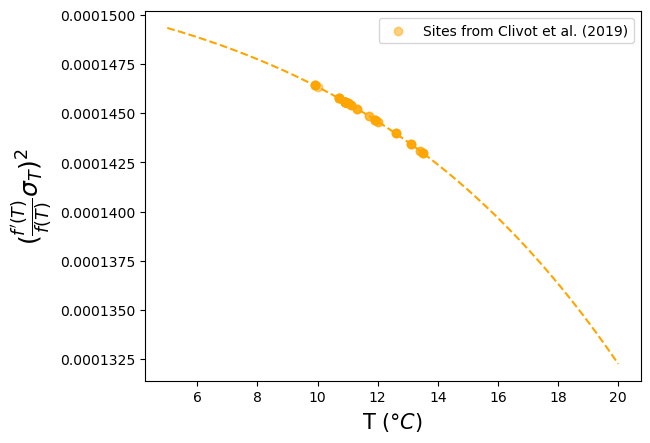

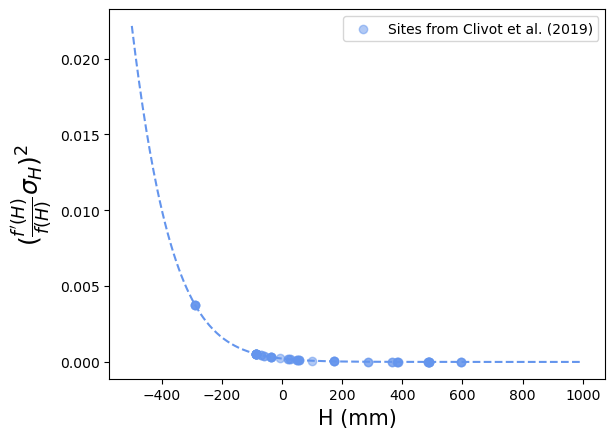

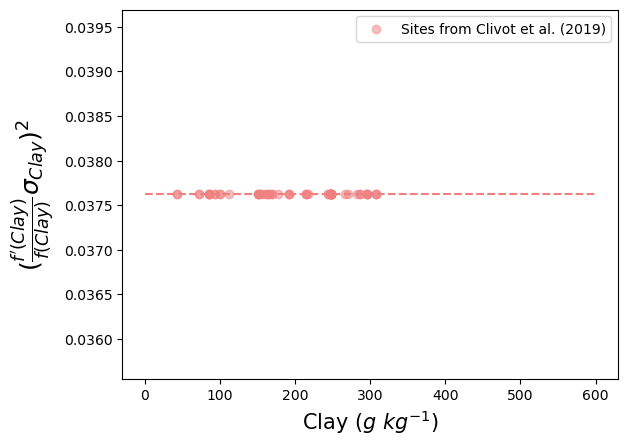

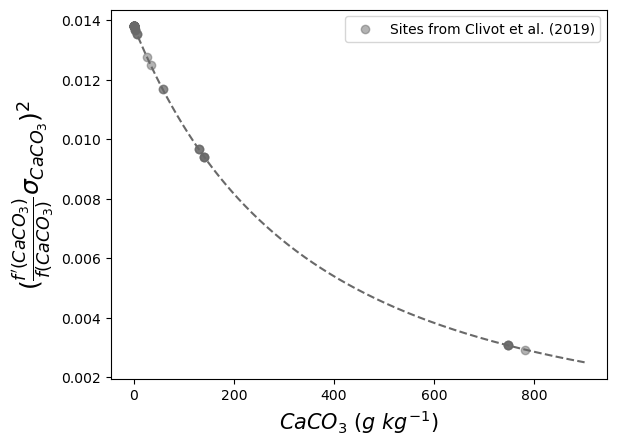

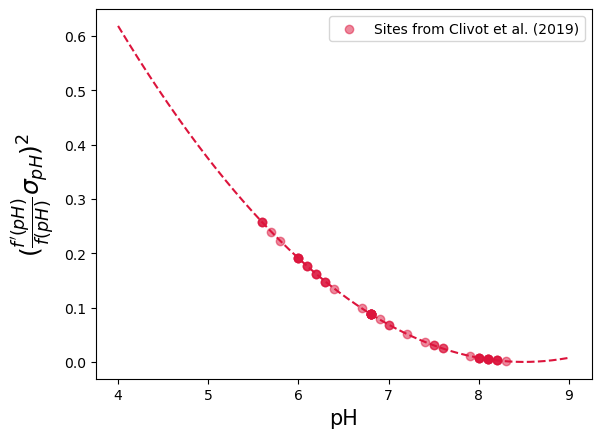

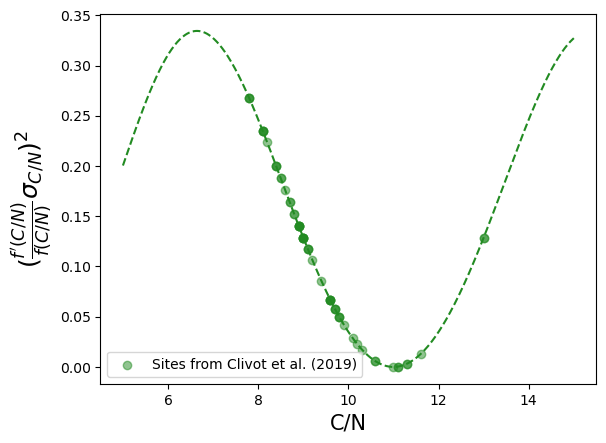

In [59]:
#%% plot each stress function contribution with the sites where it has been validated

### plot by variable, with sigma_xi constant

plt.figure()
plt.plot(forc['Temperature'], (sigma_LS['Temperature']*eps_fT(param, forc['Temperature']))**2, 
         linestyle='dashed', color='orange')
plt.scatter(data_clivot['Temp'], (sigma_LS['Temperature']*eps_fT(param, data_clivot['Temp']))**2,
            facecolor='orange',alpha=0.5,label='Sites from Clivot et al. (2019)')
plt.xlabel(r'T ($°C$)', fontsize=15)
plt.ylabel(r"$(\frac{f'(T)}{f(T)} \sigma_{T})^2$", fontsize=18)
plt.legend()


plt.figure()
plt.plot(Hm, (sigma_LS['Hm']*eps_Hm(param, Hm))**2, linestyle='dashed', color='cornflowerblue')
plt.scatter(data_clivot['P-ETP'], (sigma_LS['Hm']*eps_Hm(param, data_clivot['P-ETP']))**2, 
            facecolor='cornflowerblue',alpha=0.5,label='Sites from Clivot et al. (2019)')
plt.xlabel(r'H (mm)', fontsize=15)
plt.ylabel(r"$(\frac{f'(H)}{f(H)} \sigma_{H})^2$", fontsize=18)
plt.legend()


plt.figure()
ligne_clay = np.zeros(n) + (sigma_LS['Clay']*param['a_clay'] )**2
plt.plot(soil['Clay'], ligne_clay,linestyle='dashed', color='lightcoral')
ligne_clay = np.zeros(data_clivot['Clay'].size) + (sigma_LS['Clay']*param['a_clay'] )**2
plt.scatter(data_clivot['Clay'], ligne_clay, alpha=0.5,  facecolor='lightcoral',
            label='Sites from Clivot et al. (2019)')
plt.xlabel(r'Clay ($g~kg^{-1}$)', fontsize=15)
plt.ylabel(r"$(\frac{f'(Clay)}{f(Clay)} \sigma_{Clay})^2$", fontsize=18)
plt.legend()


plt.figure()  
plt.plot(soil['CACO3'], (sigma_LS['CACO3']*eps_CaCO3(param,soil['CACO3']))**2, 
         color='dimgray', linestyle='dashed')
plt.scatter(data_clivot['CaCO3'], (sigma_LS['CACO3']*eps_CaCO3(param,data_clivot['CaCO3']))**2, 
            facecolor='dimgray', alpha=0.5,label='Sites from Clivot et al. (2019)')
plt.xlabel(r'$CaCO_3$ ($g~kg^{-1}$)', fontsize=15)
plt.ylabel(r"$(\frac{f'(CaCO_3)}{f(CaCO_3)} \sigma_{CaCO_3})^2$", fontsize=18)
plt.legend()


plt.figure()  
plt.plot(soil['pH'], (sigma_LS['pH']*eps_pH(param,soil['pH']))**2, linestyle='dashed', color='crimson')
plt.scatter(data_clivot['pH'], (sigma_LS['pH']*eps_pH(param,data_clivot['pH']))**2, 
            facecolor='crimson', alpha=0.5, label='Sites from Clivot et al. (2019)')
plt.xlabel('pH', fontsize=15)
plt.ylabel(r"$(\frac{f'(pH)}{f(pH)} \sigma_{pH})^2$", fontsize=18)
plt.legend()

plt.figure()  
plt.plot(soil['CN_ratio'], (sigma_LS['CN_ratio']*eps_CN(param,soil['CN_ratio']))**2,
         linestyle='dashed', color='forestgreen')
plt.scatter(data_clivot['C/N'], (sigma_LS['CN_ratio']*eps_CN(param,data_clivot['C/N']))**2,
            alpha=0.5,facecolor='forestgreen',label='Sites from Clivot et al. (2019)')
plt.xlabel('C/N', fontsize=15)
plt.ylabel(r"$(\frac{f'(C/N)}{f(C/N)} \sigma_{C/N})^2$", fontsize=18)
plt.legend()


## Field-scale error scenario

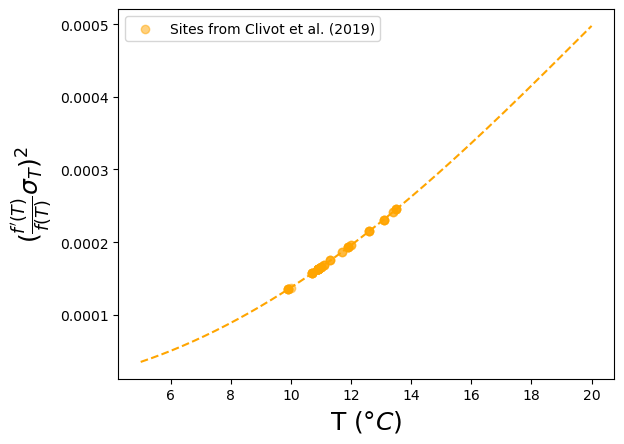

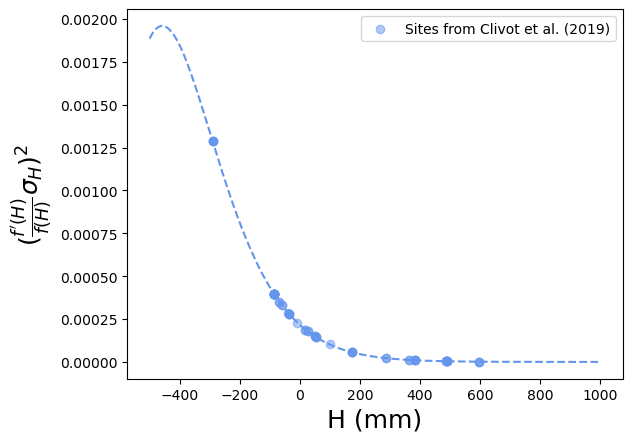

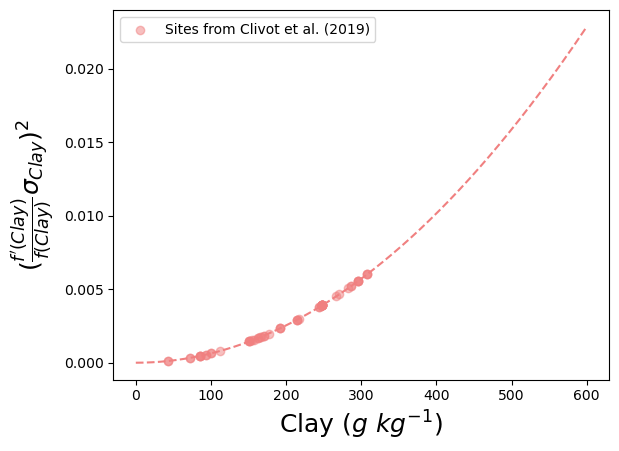

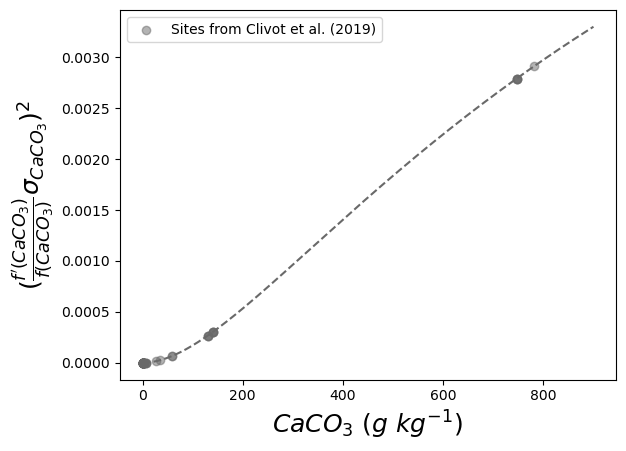

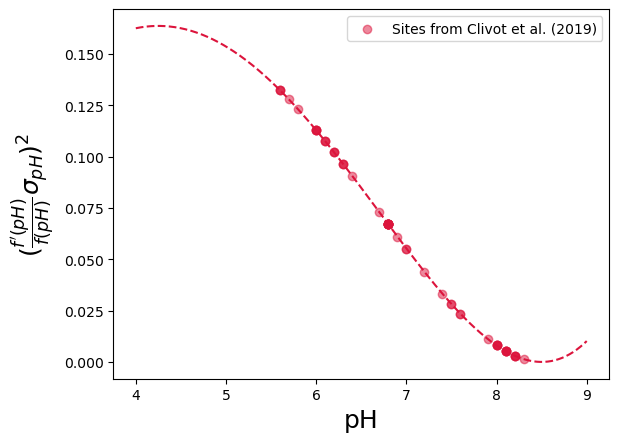

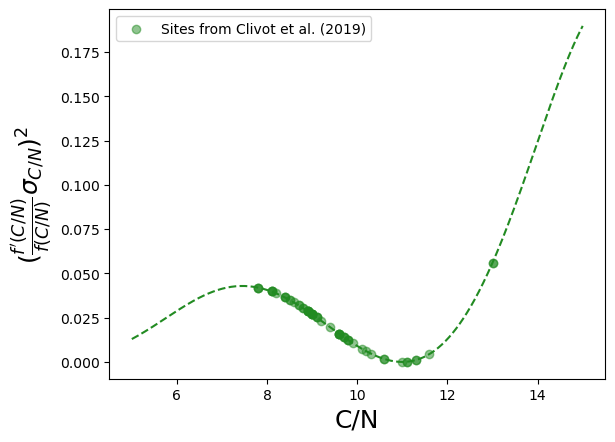

In [60]:
val_site_index = {}
val_site_index['Clay'] = np.abs(soil['Clay'][:, None] - data_clivot['Clay'].values).argmin(axis=0)
val_site_index['CACO3'] = np.abs(soil['CACO3'][:, None] - data_clivot['CaCO3'].values).argmin(axis=0)
val_site_index['pH'] =np.abs(soil['pH'][:, None] - data_clivot['pH'].values).argmin(axis=0)
val_site_index['CN_ratio'] = np.abs(soil['CN_ratio'][:, None] - data_clivot['C/N'].values).argmin(axis=0)
val_site_index['Temperature'] = np.abs(forc['Temperature'][:, None] - data_clivot['Temp'].values).argmin(axis=0)

val_site_index['Hm']=np.abs(Hm[:, None] - data_clivot['P-ETP'].values).argmin(axis=0)


plt.figure()
plt.plot(forc['Temperature'], (sigma_FS['Temperature']*eps_fT(param, forc['Temperature']))**2,
         linestyle='dashed', color='orange')
plt.scatter(data_clivot['Temp'], 
            (sigma_FS['Temperature'][val_site_index['Temperature']]*eps_fT(param, data_clivot['Temp']))**2, 
            facecolor='orange',alpha=0.5,label='Sites from Clivot et al. (2019)')
plt.xlabel(r'T ($°C$)',fontsize=18)
plt.ylabel(r"$(\frac{f'(T)}{f(T)} \sigma_{T})^2$",fontsize=18)
plt.legend()


plt.figure()
plt.plot(Hm, (sigma_FS['Hm']*eps_Hm(param, Hm))**2, linestyle='dashed', color='cornflowerblue')
plt.scatter(data_clivot['P-ETP'], 
            (sigma_FS['Hm'][val_site_index['Hm']]*eps_Hm(param, data_clivot['P-ETP']))**2,  
            facecolor='cornflowerblue',alpha=0.5,label='Sites from Clivot et al. (2019)')
plt.xlabel(r'H (mm)',fontsize=18)
plt.ylabel(r"$(\frac{f'(H)}{f(H)} \sigma_{H})^2$",fontsize=18)
plt.legend()


plt.figure()
ligne_clay = np.zeros(n) + (sigma_FS['Clay']*param['a_clay'] )**2
plt.plot(soil['Clay'], ligne_clay,linestyle='dashed', color='lightcoral')
ligne_clay = np.zeros(data_clivot['Clay'].size) + (sigma_FS['Clay'][val_site_index['Clay']]*param['a_clay'] )**2
plt.scatter(data_clivot['Clay'], ligne_clay, alpha=0.5,  facecolor='lightcoral',
            label='Sites from Clivot et al. (2019)')
plt.xlabel(r'Clay ($g~kg^{-1}$)',fontsize=18)
plt.ylabel(r"$(\frac{f'(Clay)}{f(Clay)} \sigma_{Clay})^2$",fontsize=18)
plt.legend()


plt.figure()  
plt.plot(soil['CACO3'], (sigma_FS['CACO3']*eps_CaCO3(param,soil['CACO3']))**2, color='dimgray', linestyle='dashed')
plt.scatter(data_clivot['CaCO3'], 
            (sigma_FS['CACO3'][val_site_index['CACO3']]*eps_CaCO3(param,data_clivot['CaCO3']))**2, 
            facecolor='dimgray', alpha=0.5,label='Sites from Clivot et al. (2019)')
plt.xlabel(r'$CaCO_3$ ($g~kg^{-1}$)',fontsize=18)
plt.ylabel(r"$(\frac{f'(CaCO_3)}{f(CaCO_3)} \sigma_{CaCO_3})^2$",fontsize=18)
plt.legend()


plt.figure()  
plt.plot(soil['pH'], (sigma_FS['pH']*eps_pH(param,soil['pH']))**2, linestyle='dashed', color='crimson')
plt.scatter(data_clivot['pH'], (sigma_FS['pH'][val_site_index['pH']]*eps_pH(param,data_clivot['pH']))**2, 
            facecolor='crimson', alpha=0.5, label='Sites from Clivot et al. (2019)')
plt.xlabel('pH',fontsize=18)
plt.ylabel(r"$(\frac{f'(pH)}{f(pH)} \sigma_{pH})^2$",fontsize=18)
plt.legend()

plt.figure()  
plt.plot(soil['CN_ratio'], (sigma_FS['CN_ratio']*eps_CN(param,soil['CN_ratio']))**2, 
         linestyle='dashed', color='forestgreen')
plt.scatter(data_clivot['C/N'], 
            (sigma_FS['CN_ratio'][val_site_index['CN_ratio']]*eps_CN(param,data_clivot['C/N']))**2, 
            alpha=0.5,facecolor='forestgreen',label='Sites from Clivot et al. (2019)')
plt.xlabel('C/N',fontsize=18)
plt.ylabel(r"$(\frac{f'(C/N)}{f(C/N)} \sigma_{C/N})^2$",fontsize=18)
plt.legend()